In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, RocCurveDisplay

from xgboost import XGBClassifier

In [4]:
df = pd.read_csv("loan_data.csv")

df.head()

,Age,Gender,Income,LoanAmount,Credit_History,Married,Education,Property_Area,Employment_Status,Dependents,Loan_Term,Loan_Status
0,28,Male,117196,338389,1,Yes,Graduate,Rural,Salaried,4,180,1
1,58,Female,24165,81244,0,Yes,Graduate,Rural,Business,0,360,0
2,33,Female,48893,521029,1,Yes,Graduate,Rural,Self Employed,2,240,0
3,30,Male,145463,402944,0,Yes,Not Graduate,Urban,Self Employed,2,360,0
4,37,Male,115647,531741,0,No,Graduate,Rural,Self Employed,4,240,0


In [5]:
print(df.shape)

df.info()

df.describe()

df.isnull().sum()

(500, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                500 non-null    int64 
 1   Gender             500 non-null    object
 2   Income             500 non-null    int64 
 3   LoanAmount         500 non-null    int64 
 4   Credit_History     500 non-null    int64 
 5   Married            500 non-null    object
 6   Education          500 non-null    object
 7   Property_Area      500 non-null    object
 8   Employment_Status  500 non-null    object
 9   Dependents         500 non-null    int64 
 10  Loan_Term          500 non-null    int64 
 11  Loan_Status        500 non-null    int64 
dtypes: int64(7), object(5)
memory usage: 47.0+ KB


Age                  0
Gender               0
Income               0
LoanAmount           0
Credit_History       0
Married              0
Education            0
Property_Area        0
Employment_Status    0
Dependents           0
Loan_Term            0
Loan_Status          0
dtype: int64

In [6]:
encoder = LabelEncoder()

categorical = ["Gender","Married","Education","Property_Area","Employment_Status"]

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Age,Gender,Income,LoanAmount,Credit_History,Married,Education,Property_Area,Employment_Status,Dependents,Loan_Term,Loan_Status
0,28,1,117196,338389,1,1,0,0,1,4,180,1
1,58,0,24165,81244,0,1,0,0,0,0,360,0
2,33,0,48893,521029,1,1,0,0,2,2,240,0
3,30,1,145463,402944,0,1,1,2,2,2,360,0
4,37,1,115647,531741,0,0,0,0,2,4,240,0


In [7]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Accuracy : 0.95
              precision    recall  f1-score   support

           0       1.00      0.86      0.93        36
           1       0.93      1.00      0.96        64

    accuracy                           0.95       100
   macro avg       0.96      0.93      0.94       100
weighted avg       0.95      0.95      0.95       100



C:\Users\sony\anaconda4\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

Accuracy : 0.98
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        36
           1       1.00      0.97      0.98        64

    accuracy                           0.98       100
   macro avg       0.97      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



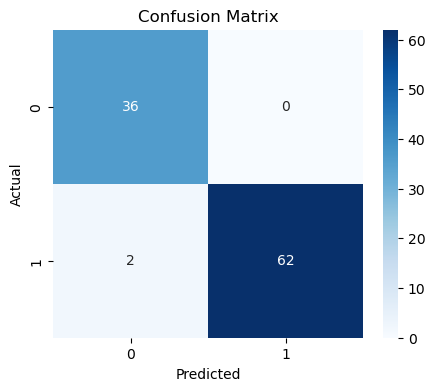

In [11]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

AUC ROC Score : 1.0


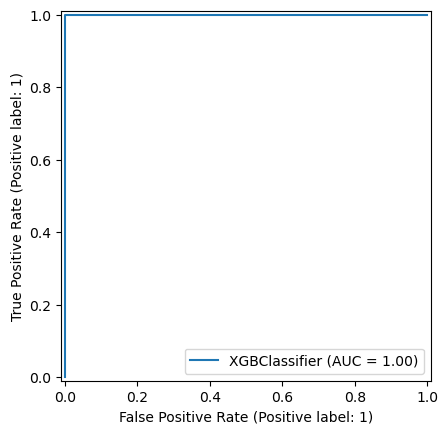

In [12]:
prob = xgb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, prob)

print("AUC ROC Score :", auc)

RocCurveDisplay.from_estimator(
    xgb,
    X_test,
    y_test
)

plt.show()

              Feature  Importance
4      Credit_History    0.727356
2              Income    0.144994
3          LoanAmount    0.126769
0                 Age    0.000264
1              Gender    0.000245
6           Education    0.000228
9          Dependents    0.000145
5             Married    0.000000
7       Property_Area    0.000000
8   Employment_Status    0.000000
10          Loan_Term    0.000000


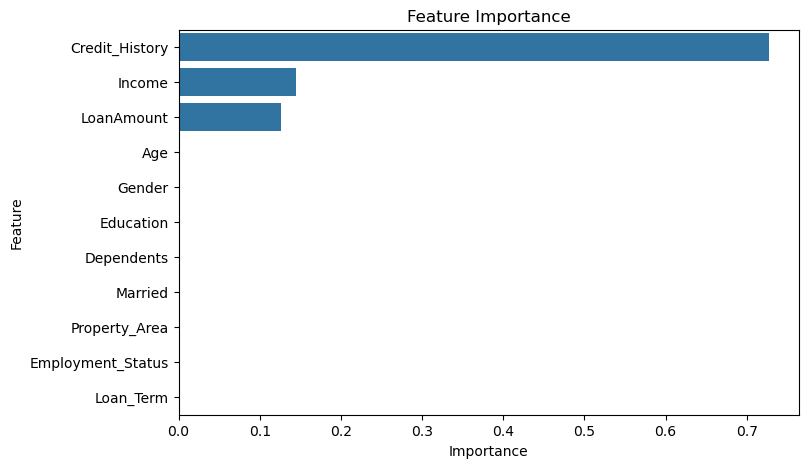

In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

In [14]:
import joblib

joblib.dump(xgb, "loan_default_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [15]:
sample = pd.DataFrame({
    "Age":[35],
    "Gender":[1],
    "Income":[70000],
    "LoanAmount":[250000],
    "Credit_History":[1],
    "Married":[1],
    "Education":[0],
    "Property_Area":[2],
    "Employment_Status":[1],
    "Dependents":[2],
    "Loan_Term":[360]
})

prediction = xgb.predict(sample)

if prediction[0] == 1:
    print("Loan Approved / Low Default Risk")
else:
    print("Loan Rejected / High Default Risk")

Loan Approved / Low Default Risk
